# Streaming XGBoost Forward Return

Build LOB features from MBO data, add a forward-return target, then run rolling time-series validation with the streaming `XGBoostAdapter`.

In [1]:
# Source - https://stackoverflow.com/a/10472712
# Posted by Andrew_1510, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-28, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import polars as pl
from matplotlib import pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.data import FeatureLoader, expand_dates
from tools.features import LOBFeatures, depth_meta
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import XGBoostAdapter
from tools.pipeline import Pipeline
from tools.score import get_pinball, get_quantile_pnl, get_unit_pnl, rmse
from tools.search import categorical, int_, loguniform, uniform

In [3]:
expand_dates("20260501-20260507")

['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07']

In [4]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(
            expand_dates(
                f"{args[i - 1]}-{args[i]}",
                end_date=False if i < len(args) - 1 else True,
            )
        )
    return dates

In [ ]:
# Data
PROD = "ES"
# ROLLING_DATES = [["2026-05-01", "2026-05-04", "2026-05-05"], ["2026-05-06"], ["2026-05-07"]]
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260529)
TEST_DATES = ["2026-05-06"]
L2_DEPTH = 5
MODEL_BATCH_SIZE = 200_000
POLARS_ENGINE = "streaming"
ORDERBOOK_PATH = str(ROOT / f"data/orderbook_l2_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}.parquet")
RAW_CONTEXT_COLS = ("ts_event", "instrument_id")
# RAW_CONTEXT_COLS = ("ts_event", "ts_recv", "symbol")
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Feature knobs
IMBALANCE_DEPTHS = [1, 3, 5]
IMBALANCE_LOG = True
TRADE_MOMENTUM_LOG = True
WEIGHTED_PRICE_DEPTH = 5
WEIGHTED_PRICE_SIZES = [2, 5, 10]
TRADE_MOMENTUM_HALF_LIVES = [1, 10, 30, 120]  # seconds

# Forward-return target knobs
FUTURE_HORIZONS = ["10s", "30s", "60s"]
FUTURE_WEIGHTS = [0.5, 0.3, 0.2]
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# XGBoost/search knobs
SAMPLER = "random"
N_TRIALS = 20
NUM_BOOST_ROUND = 300
EARLY_STOPPING_ROUNDS = 25
QUANTILES = [0.1, 0.5, 0.9]  # adapter sets objective=reg:quantileerror + quantile_alpha
MEDIAN_IDX = QUANTILES.index(0.5)
SEARCH_SPACE = {
    "eval_metric": categorical(["quantile"]),
    "tree_method": categorical(["hist"]),
    # "device": categorical(["cuda"]),
    "max_depth": int_(2, 6),
    "eta": loguniform(0.01, 0.2),
    "subsample": uniform(0.6, 1.0),
    "colsample_bytree": uniform(0.5, 1.0),
    "min_child_weight": loguniform(1.0, 100.0),
    "lambda": loguniform(1e-3, 100.0),
    "alpha": loguniform(1e-4, 10.0),
}


def median_quantile(score):
    # Multi-quantile predict() returns (n, len(QUANTILES)); score point metrics on the median column.
    def wrapped(y_true, y_pred, ctx=None, **kwargs):
        y_pred = np.asarray(y_pred)
        if y_pred.ndim == 2:
            y_pred = y_pred[:, MEDIAN_IDX]
        return score(y_true, y_pred, ctx, **kwargs)

    wrapped.__name__ = f"median_{getattr(score, '__name__', 'score')}"
    return wrapped


UNDEF_PRICE = 9_223_372_036_854_775_807
assert L2_DEPTH >= max([*IMBALANCE_DEPTHS, WEIGHTED_PRICE_DEPTH])
TICKSIZE = 250000000

In [6]:
def tag(x: object) -> str:
    return str(x).replace(".", "p")


def feature_exprs() -> dict[str, pl.Expr]:
    exprs = {}
    for depth in IMBALANCE_DEPTHS:
        exprs[f"imb_d{depth}"] = LOBFeatures.book_imbalance(depth, log=IMBALANCE_LOG)
    for size in sorted(set([*WEIGHTED_PRICE_SIZES])):
        exprs[f"weighted_price_sz{tag(size)}"] = LOBFeatures.size_weighted_avg_price(
            WEIGHTED_PRICE_DEPTH,
            size,
        )
    return exprs


def stateful_features() -> tuple[LOBFeatures.TradeMomentum, ...]:
    return tuple(
        LOBFeatures.TradeMomentum(
            f"trade_momentum_hl{tag(half_life)}s",
            half_life,
            log=TRADE_MOMENTUM_LOG,
        )
        for half_life in TRADE_MOMENTUM_HALF_LIVES
    )


FEATURE_EXPRS = feature_exprs()
STATEFUL_FEATURES = stateful_features()
FEATURES = [*FEATURE_EXPRS, *[feature.name for feature in STATEFUL_FEATURES]]
# FEATURES = ["imb_d1"]
# FEATURES = ["weighted_price_sz5"]

MID = (pl.col("bid_px_0") + pl.col("ask_px_0")) / 2
# META_COLS = ["ts_event", "ts_recv", "symbol", *depth_meta(L2_DEPTH)]
META_COLS = ["ts_event", "instrument_id", *depth_meta(L2_DEPTH)]
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))
FEATURES

['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'trade_momentum_hl10s',
 'trade_momentum_hl30s',
 'trade_momentum_hl120s']

In [7]:
REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x7301AA857B00>

In [8]:
loader = FeatureLoader(
    prod=PROD,
    feature_exprs=FEATURE_EXPRS,
    stateful_features=STATEFUL_FEATURES,
    return_exprs={TARGET: MID},
    horizons=FUTURE_HORIZONS,
    weights=FUTURE_WEIGHTS,
    l2_depth=None,
    path=ORDERBOOK_PATH,
    return_time="ts_event",
    return_by=("publisher_id", "instrument_id"),
)


In [9]:
from tools.data import DataSource

FEATURE_TEST_SCORE = get_unit_pnl(TEST_PNL_THRESHOLD)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores

feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz5""","""unit_pnl_0.2""",0.564505,628,6142810
"""weighted_price_sz10""","""unit_pnl_0.2""",0.151553,1249,6142810
"""imb_d5""","""unit_pnl_0.2""",0.102012,4696475,6142810
"""imb_d3""","""unit_pnl_0.2""",0.096836,4982688,6142810
"""imb_d1""","""unit_pnl_0.2""",0.095639,5519127,6142810
"""trade_momentum_hl1s""","""unit_pnl_0.2""",0.046816,5408133,6142810
"""trade_momentum_hl10s""","""unit_pnl_0.2""",0.039836,4614818,6142810
"""trade_momentum_hl30s""","""unit_pnl_0.2""",0.037284,4217412,6142810
"""trade_momentum_hl120s""","""unit_pnl_0.2""",0.034171,2991915,6142810


CV folds can early-stop because they have validation data. The final refit uses the best Optuna params and trains fixed `NUM_BOOST_ROUND`; CV `best_iteration` metadata is recorded on the best trial for inspection.

In [ ]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=XGBoostAdapter(
        num_boost_round=NUM_BOOST_ROUND,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        batch_size=MODEL_BATCH_SIZE,
        streaming=True,
        quantiles=QUANTILES,
    ),
    target=TARGET,
    features=FEATURES,
    data_loader=loader,
    search_space=SEARCH_SPACE,
    val_score=get_pinball(QUANTILES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(VALID_REGULAR_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline

In [11]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [12]:
src = DataSource(
    dates=ROLLING_DATES[-1][-1:],
    loader=loader,
    target=TARGET,
    features=FEATURES + ["ts_event", "bid_px_0", "ask_px_0"],
    filters=(VALID_ROWS,),
    polars_engine=POLARS_ENGINE,
)

df = src.frame()[::1000].collect(engine=POLARS_ENGINE)
sprd = 2.0 * (pl.col("ask_px_0") - pl.col("bid_px_0")) / (pl.col("ask_px_0") + pl.col("bid_px_0")) * 1e4
print(src.frame().select(sprd).min().collect(engine=POLARS_ENGINE))
df.head()

shape: (1, 1)
┌──────────┐
│ literal  │
│ ---      │
│ f64      │
╞══════════╡
│ 0.328445 │
└──────────┘


imb_d1,imb_d3,imb_d5,weighted_price_sz2,weighted_price_sz5,weighted_price_sz10,trade_momentum_hl1s,trade_momentum_hl10s,trade_momentum_hl30s,trade_momentum_hl120s,ts_event,bid_px_0,ask_px_0,forward_mid_return_bps,date,nature
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"datetime[ns, UTC]",i64,i64,f64,str,str
0.0,1.051369,1.546482,-1.409718,-2.653752,-2.653752,0.0,0.0,0.0,0.0,2026-05-24 12:00:05.480509575 UTC,7477000000000,7598000000000,0.0,"""2026-05-29""","""extra_normal"""
0.693147,0.449311,0.973585,0.082387,0.032955,0.049432,0.0,0.0,0.0,0.0,2026-05-28 23:30:01.398354631 UTC,7584000000000,7588250000000,0.0,"""2026-05-29""","""extra_normal"""
1.098612,0.710743,0.560252,0.0,0.032962,0.098887,-4.092203,-3.848049,-3.827054,-3.819126,2026-05-29 00:00:02.202008799 UTC,7584250000000,7584500000000,0.065925,"""2026-05-29""","""extra_normal"""
-1.446919,-0.883421,-0.71783,0.0,-0.032959,-0.098878,3.827907,-0.201393,-0.492244,-0.598712,2026-05-29 00:00:17.469742119 UTC,7585000000000,7585250000000,-0.840461,"""2026-05-29""","""extra_normal"""
-0.693147,-0.377708,-0.298728,0.0,0.0,-0.065925,1.941646,0.359458,0.258893,0.168716,2026-05-29 00:00:44.344309999 UTC,7584250000000,7584500000000,-0.461475,"""2026-05-29""","""extra_normal"""


[[ 1.00000000e+00  9.33203201e-01  9.11294791e-01  4.01153789e-01
   5.74674582e-01  7.51444911e-01  3.77569572e-03  1.35794915e-02
   9.99940173e-03 -9.63418882e-04]
 [ 9.33203201e-01  1.00000000e+00  9.89261983e-01  2.64112629e-01
   4.45658401e-01  6.44816732e-01 -3.82931420e-02 -1.83280263e-02
  -1.92530228e-02 -3.13504997e-02]
 [ 9.11294791e-01  9.89261983e-01  1.00000000e+00  2.42002123e-01
   4.23109286e-01  6.20146425e-01 -4.61568997e-02 -3.10840875e-02
  -3.27334075e-02 -4.60416568e-02]
 [ 4.01153789e-01  2.64112629e-01  2.42002123e-01  1.00000000e+00
   8.19505334e-01  6.51318622e-01  2.40818441e-02  2.60663213e-02
   2.38026200e-02  1.86461249e-02]
 [ 5.74674582e-01  4.45658401e-01  4.23109286e-01  8.19505334e-01
   1.00000000e+00  8.98559113e-01  1.63475604e-02  2.31756154e-02
   1.98218002e-02  1.56523222e-02]
 [ 7.51444911e-01  6.44816732e-01  6.20146425e-01  6.51318622e-01
   8.98559113e-01  1.00000000e+00  9.05297966e-03  1.77188703e-02
   1.40378961e-02  1.19305042e-02

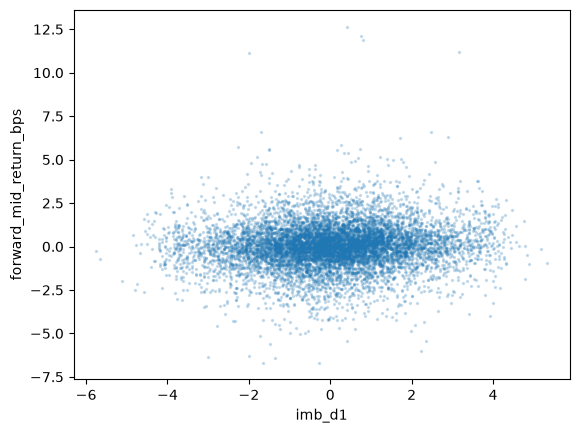

imb_d3 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d3   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.069992 ┆ 1.29621                │
└──────────┴────────────────────────┘


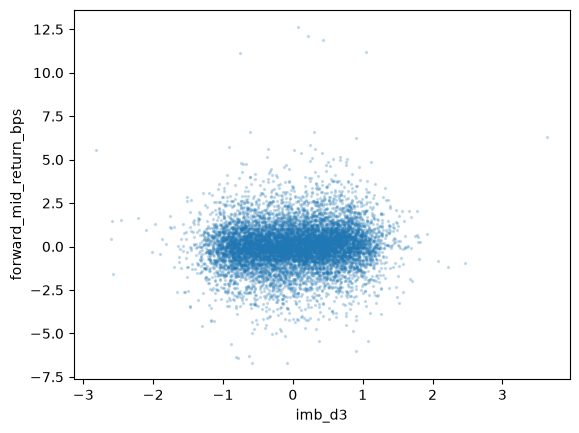

imb_d5 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d5   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.071539 ┆ 1.29621                │
└──────────┴────────────────────────┘


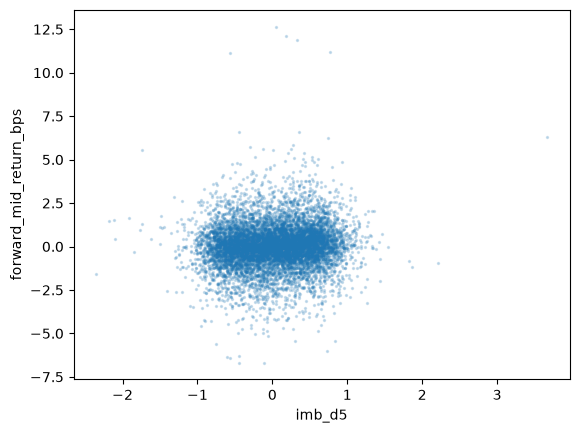

weighted_price_sz2 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz2 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.022927           ┆ 1.29621                │
└────────────────────┴────────────────────────┘


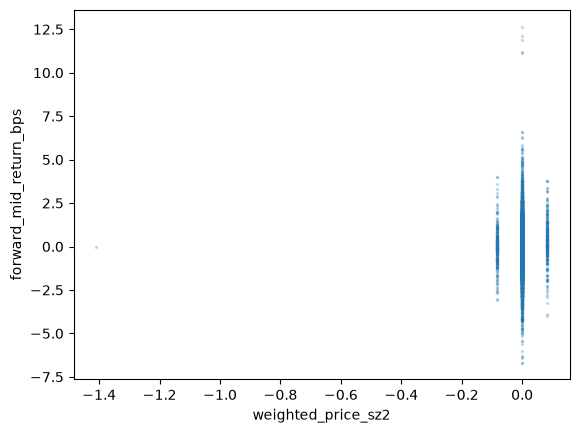

weighted_price_sz5 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz5 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.047727           ┆ 1.29621                │
└────────────────────┴────────────────────────┘


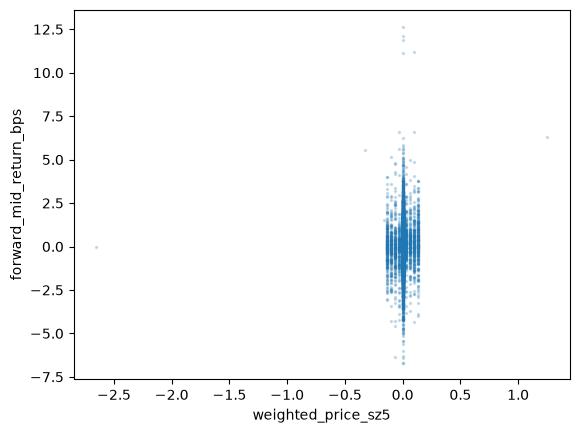

weighted_price_sz10 shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ weighted_price_sz10 ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ 0.060395            ┆ 1.29621                │
└─────────────────────┴────────────────────────┘


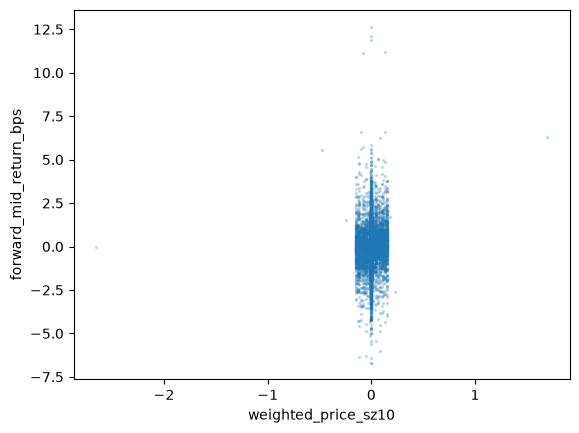

trade_momentum_hl1s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ trade_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.020937           ┆ 1.29621                │
└─────────────────────┴────────────────────────┘


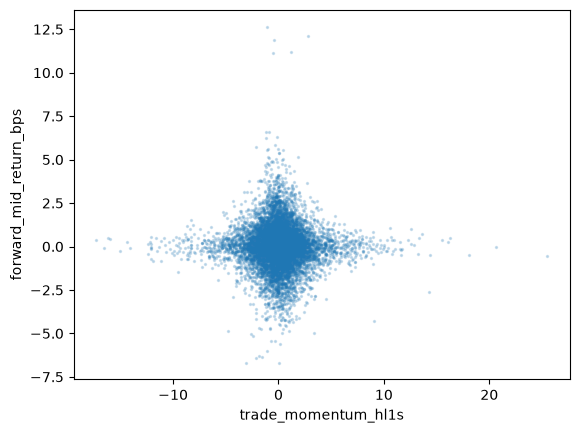

trade_momentum_hl10s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.054416            ┆ 1.29621                │
└──────────────────────┴────────────────────────┘


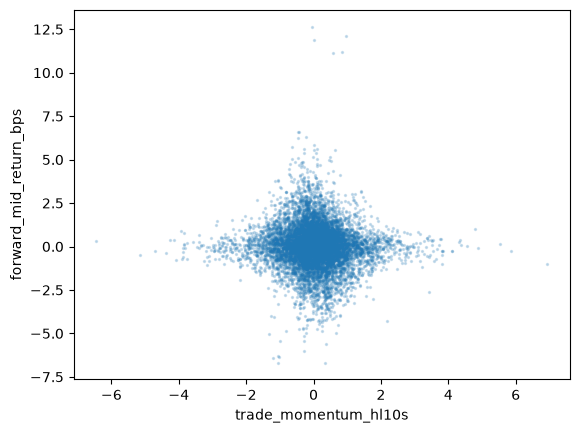

trade_momentum_hl30s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.047307            ┆ 1.29621                │
└──────────────────────┴────────────────────────┘


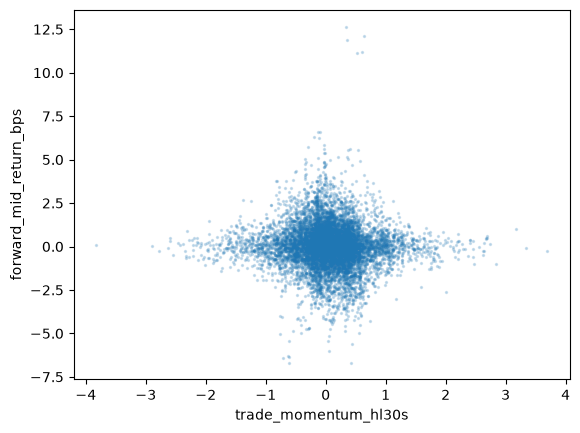

trade_momentum_hl120s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ 0.008746              ┆ 1.29621                │
└───────────────────────┴────────────────────────┘


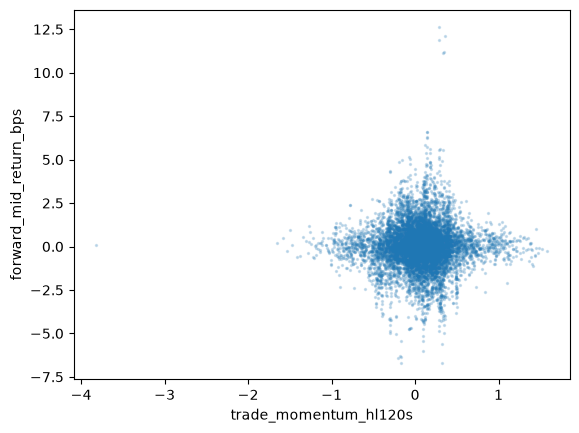

In [13]:
corr = np.zeros((len(FEATURES), len(FEATURES)))
for i, feature_i in enumerate(FEATURES):
    for j, feature_j in enumerate(FEATURES):
        corr[i, j] = df.select(pl.corr(pl.col(feature_i), pl.col(feature_j)))[0].item()
print(corr)

for feature in FEATURES:
    print(feature, df.select(pl.corr(pl.col(feature), pl.col(TARGET)), pl.col(TARGET).std()))
    plt.scatter(df[feature], df[TARGET], s=2, alpha=0.2)
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.show()

In [ ]:
train_result = pipeline.train(verbose=2)
train_result

/home/jli/projects/rep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-29 10:57:34,560] A new study created in memory with name: no-name-19a2531b-02d1-4a64-a6cf-21dfe68c3aed


======== Optuna study created. Launching optimization.
======== running params {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'max_depth': 3, 'eta': 0.07627978327947023, 'subsample': 0.6485195270801957, 'colsample_bytree': 0.6790974081696863, 'min_child_weight': 1.6155549402578913, 'lambda': 6.815767527869045, 'alpha': 0.005425979076334005}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


In [ ]:
best_trial_attrs = pipeline.study.best_trial.user_attrs
xgb_fits = pl.DataFrame(best_trial_attrs.get("xgb_fits", []))
xgb_round_summary = {
    "median": best_trial_attrs.get("xgb_cv_best_num_boost_round_median"),
    "max": best_trial_attrs.get("xgb_cv_best_num_boost_round_max"),
    "fold_rounds": best_trial_attrs.get("xgb_cv_best_num_boost_rounds"),
}
xgb_round_summary, xgb_fits

In [ ]:
rmse_result = pipeline.test(median_quantile(rmse))
rmse_result

In [ ]:
pinball_result = pipeline.test(get_pinball(QUANTILES))

interval_src = DataSource(
    dates=TEST_DATES,
    loader=loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true_test, _ = interval_src.labels()
y_pred_q = pinball_result["y_pred"]
lo, hi = y_pred_q[:, 0], y_pred_q[:, -1]
coverage = float(np.mean((y_true_test >= lo) & (y_true_test <= hi)))
width = float(np.mean(hi - lo))
target_coverage = QUANTILES[-1] - QUANTILES[0]
print(f"pinball = {pinball_result['test_score']:.6f}")
print(f"interval coverage = {coverage:.4f} (target {target_coverage:.2f})")
print(f"mean interval width = {width:.4f} bps")

In [ ]:
pnl_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=0.0,
        thd_sell=0.0,
    )
)
pnl_result

In [ ]:
pnl_threshold_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=TEST_PNL_THRESHOLD * 1.5,
        thd_sell=-(TEST_PNL_THRESHOLD * 1.5),
    )
)
pnl_threshold_result

In [ ]:
y_pred_q = pnl_threshold_result["y_pred"]
_ = plt.hist(y_pred_q, bins=100, log=True, density=False, label=[f"q={q}" for q in QUANTILES])
plt.legend()
plt.xlabel("prediction")
plt.ylabel("count")

In [ ]:
booster = pipeline.get_model()
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")

df_importance = pl.DataFrame(
    [
        {
            "feature": feature,
            "gain": float(gain.get(f"f{idx}", gain.get(feature, 0.0))),
            "weight": float(weight.get(f"f{idx}", weight.get(feature, 0.0))),
        }
        for idx, feature in enumerate(FEATURES)
    ]
).sort("gain", descending=True)

df_importance

In [ ]:
test_src = DataSource(
    dates=TEST_DATES,
    loader=loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true, _ = test_src.labels()
pred_eval = pl.DataFrame({"y_true": y_true, "y_pred": pnl_threshold_result["y_pred"][:, MEDIAN_IDX]})
n_pred = pred_eval.height
pred_eval = pred_eval.with_columns(
    (((pl.col("y_pred").rank("average") - 1) * 10 / n_pred).floor().clip(0, 9).cast(pl.Int8)).alias("pred_decile")
)

pred_eval.group_by("pred_decile").agg(
    pl.len().alias("n"),
    pl.col("y_pred").mean().alias("mean_pred"),
    pl.col("y_true").mean().alias("mean_forward_return_bps"),
    (pl.col("y_true") * pl.col("y_pred").sign()).mean().alias("mean_signed_return_bps"),
).sort("pred_decile")